In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

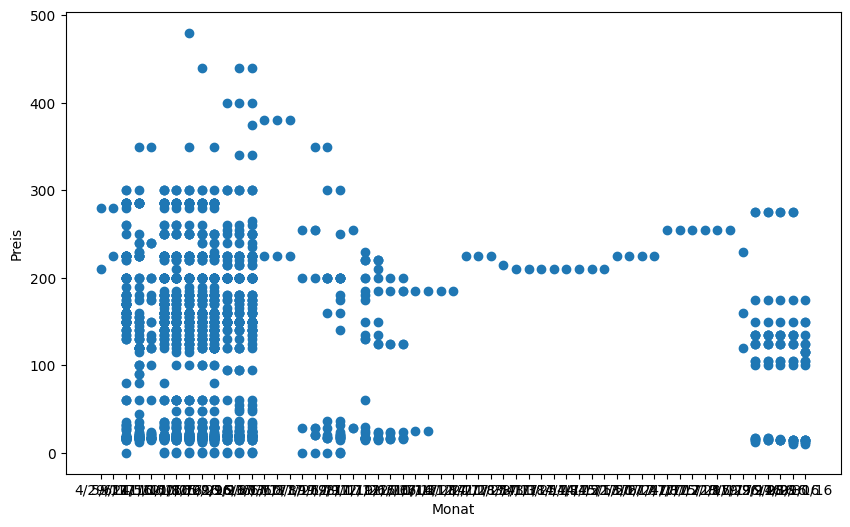

In [2]:
pumpkins = pd.read_csv("../../data/US-pumpkins.csv")

#print(pumpkins.info())
#print(pumpkins.shape)
#print(pumpkins.head(10))
plt.figure(figsize=(10,6))
plt.scatter(pumpkins["Date"], pumpkins["High Price"])
plt.xlabel("Monat")
plt.ylabel("Preis")
plt.show()
#print(pumpkins["Date"])

In [3]:
#print(pumpkins.isna()) # Zeigt für jeden Eintrag, ob er Vorhanden ist oder nicht.
print(pumpkins.isna().sum()) # Zählt die Nicht vorhandenen Einträge jeder Spalte zusammen.
print(pumpkins.isna().any().any()) # Guckt, ob überhaupt fahlende Einträge vorhanden sind.

City Name             0
Type               1712
Package               0
Variety               5
Sub Variety        1461
Grade              1757
Date                  0
Low Price             0
High Price            0
Mostly Low          103
Mostly High         103
Origin                3
Origin District    1626
Item Size           279
Color               616
Environment        1757
Unit of Sale       1595
Quality            1757
Condition          1757
Appearance         1757
Storage            1757
Crop               1757
Repack                0
Trans Mode         1757
Unnamed: 24        1757
Unnamed: 25        1654
dtype: int64
True


In [4]:
pumpkins_filled = pumpkins.fillna(0) # Ersetzt fehlende Einträge durch 0
#pumpkins["A"] = pumpkins["A"].fillna(pumpkins["A"].mean()) # Füllt fehlende Werte mit dem Mittelwert

print(pumpkins_filled.isna().sum())

City Name          0
Type               0
Package            0
Variety            0
Sub Variety        0
Grade              0
Date               0
Low Price          0
High Price         0
Mostly Low         0
Mostly High        0
Origin             0
Origin District    0
Item Size          0
Color              0
Environment        0
Unit of Sale       0
Quality            0
Condition          0
Appearance         0
Storage            0
Crop               0
Repack             0
Trans Mode         0
Unnamed: 24        0
Unnamed: 25        0
dtype: int64


In [5]:
smalllist_pumpkins_filled = pumpkins_filled[["Package", "High Price", "Low Price", "Date"]]

In [6]:
print(smalllist_pumpkins_filled.head(10))

        Package  High Price  Low Price      Date
0  24 inch bins       280.0      270.0   4/29/17
1  24 inch bins       280.0      270.0    5/6/17
2  24 inch bins       160.0      160.0   9/24/16
3  24 inch bins       160.0      160.0   9/24/16
4  24 inch bins       100.0       90.0   11/5/16
5  24 inch bins       100.0       90.0  11/12/16
6  36 inch bins       170.0      160.0   9/24/16
7  36 inch bins       160.0      160.0   9/24/16
8  36 inch bins       170.0      160.0   10/1/16
9  36 inch bins       160.0      160.0   10/1/16


In [7]:
smalllist_pumpkins_filled["Date"] = pd.to_datetime(smalllist_pumpkins_filled["Date"], infer_datetime_format=True, errors="coerce")
smalllist_pumpkins_filled["Month"] = smalllist_pumpkins_filled["Date"].dt.month
smalllist_pumpkins_filled["Price"] = (smalllist_pumpkins_filled["High Price"]+smalllist_pumpkins_filled["Low Price"])/2

#print(smalllist_pumpkins_filled["Month"], smalllist_pumpkins_filled["Package"]) # Viele verschiedene Verpackungsgrößen

new_smalllist_pumpkins_filled = smalllist_pumpkins_filled[smalllist_pumpkins_filled["Package"].str.contains("bushel", na=False)]
#print(new_smalllist_pumpkins_filled) # Preis ist für unterschiedliche große bushel


/var/folders/9x/4r85cksj2qb4bfrshx81bg180000gr/T/ipykernel_33991/3253695984.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  smalllist_pumpkins_filled["Date"] = pd.to_datetime(smalllist_pumpkins_filled["Date"], infer_datetime_format=True, errors="coerce")
/var/folders/9x/4r85cksj2qb4bfrshx81bg180000gr/T/ipykernel_33991/3253695984.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  smalllist_pumpkins_filled["Date"] = pd.to_datetime(smalllist_pumpkins_filled["Date"], infer_datetime_format=True, errors="coerce")
/var/folders/9x/4r85cksj2qb4bfrshx81bg180000gr/T/ipykernel_33991/3253695984.py:1: SettingWithCopyWarning: 
A value is tryin

In [8]:
def richtiger_Preis(row):
    if "1 1/9" in row["Package"]:
        return row["Price"] / (1 + 1/9)
    elif "1/2" in row["Package"]:
        return row["Price"] / (1/2)
    else:
        return row["Price"]
        
new_smalllist_pumpkins_filled["Price"] = new_smalllist_pumpkins_filled.apply(richtiger_Preis, axis=1)
print(new_smalllist_pumpkins_filled)
print(new_smalllist_pumpkins_filled["Price"])

                   Package  High Price  Low Price       Date  Month  Price
70    1 1/9 bushel cartons        15.0      15.00 2016-09-24      9  13.50
71    1 1/9 bushel cartons        18.0      18.00 2016-09-24      9  16.20
72    1 1/9 bushel cartons        18.0      18.00 2016-10-01     10  16.20
73    1 1/9 bushel cartons        17.0      17.00 2016-10-01     10  15.30
74    1 1/9 bushel cartons        15.0      15.00 2016-10-08     10  13.50
...                    ...         ...        ...        ...    ...    ...
1738    1/2 bushel cartons        15.0      15.00 2016-09-30      9  30.00
1739    1/2 bushel cartons        15.0      13.75 2016-09-30      9  28.75
1740    1/2 bushel cartons        15.0      10.75 2016-09-30      9  25.75
1741    1/2 bushel cartons        12.0      12.00 2016-09-30      9  24.00
1742    1/2 bushel cartons        12.0      12.00 2016-09-30      9  24.00

[415 rows x 6 columns]
70      13.50
71      16.20
72      16.20
73      15.30
74      13.50
      

/var/folders/9x/4r85cksj2qb4bfrshx81bg180000gr/T/ipykernel_33991/269794940.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_smalllist_pumpkins_filled["Price"] = new_smalllist_pumpkins_filled.apply(richtiger_Preis, axis=1)


In [10]:
# relocate Spalte "Month"
cols = ["Month"] + [col for col in new_smalllist_pumpkins_filled.columns if col != "Month"]
new_smalllist_pumpkins_filled = new_smalllist_pumpkins_filled[cols]

# Erste 7 Zeilen anzeigen
print(new_smalllist_pumpkins_filled .head(7))

    Month               Package  High Price  Low Price       Date  Price
70      9  1 1/9 bushel cartons        15.0       15.0 2016-09-24   13.5
71      9  1 1/9 bushel cartons        18.0       18.0 2016-09-24   16.2
72     10  1 1/9 bushel cartons        18.0       18.0 2016-10-01   16.2
73     10  1 1/9 bushel cartons        17.0       17.0 2016-10-01   15.3
74     10  1 1/9 bushel cartons        15.0       15.0 2016-10-08   13.5
75     10  1 1/9 bushel cartons        18.0       18.0 2016-10-08   16.2
76     10  1 1/9 bushel cartons        17.0       17.0 2016-10-08   15.3


<Axes: xlabel='Price', ylabel='Month'>

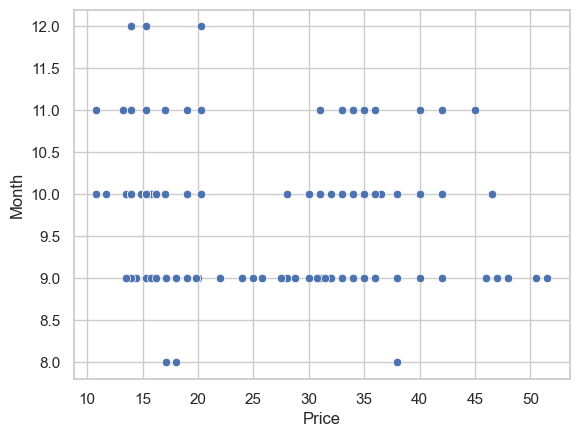

In [12]:
sns.set_theme(style="whitegrid")
sns.scatterplot(data=new_smalllist_pumpkins_filled, x="Price", y="Month")

   Month  Mean_Price
0      8   24.366667
1      9   28.544384
2     10   28.355244
3     11   25.067213
4     12   15.412500


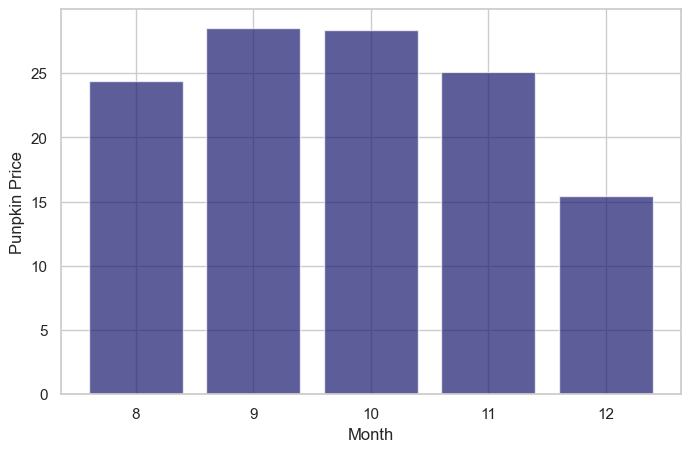

In [19]:
monthly_average = (new_smalllist_pumpkins_filled.groupby("Month", as_index=False)["Price"].mean().rename(columns={"Price": "Mean_Price"}))
print(monthly_average)

plt.figure(figsize=(8,5))
plt.bar(monthly_average["Month"], monthly_average["Mean_Price"], color="midnightblue", alpha=0.7)
plt.xlabel("Month")
plt.ylabel("Punpkin Price")
plt.show()